In [ ]:
options(future.globals.maxSize = 100000000 * 1024^2)

# set random seed for reproducibility
set.seed(12345)

# ========================= Libraries ===================================


## We load the required packages
library(dplyr)
library(Seurat)
library(readr)
library(readr)
# single-cell analysis package
# plotting and data science packages
# library(tidyverse)
library(cowplot)
library(patchwork)
library(ggplot2)
# co-expression network analysis packages:
library(igraph)
library(harmony)
library(dittoSeq)
library(RColorBrewer)

library(org.Hs.eg.db)
require(tidyverse)
library(clusterProfiler)
library(WGCNA)
library(hdWGCNA)
library(scCustomize)
library(harmony)


library(SCopeLoomR)
library(dreamlet)
library(SingleCellExperiment)
library(scater)
# library(UCell)
# library(Nebulosa)

library(SingleCellExperiment)
library(scuttle)
library(Seurat)
library(doParallel)
'%notin%' <- Negate('%in%')

# plotting
library(ggplot2)
library(dplyr)
library(RColorBrewer)
library(cowplot)
library(ggtree)
library(aplot)
library(circlize)
library(ComplexHeatmap)

# meta
library(tidyr)
library(muscat)
library(broom)
library(tidyverse)
library(metafor) 

input_rds <- args[1]
group_by <- args[2]
only_microglia <- as.logical(args[3])
n_of_aggregated <- as.numeric(args[4]) # 25
n_of_aggregated_text <- args[4]
threads <- as.numeric(args[5])
output_pdf <- args[6]

workdir <- "7.WGCNA/"
source('utils.R')
dir.create(workdir)
registerDoParallel(cores=threads)
colors <- brewer.pal(n = 9, name = 'Set3')
colors[2] <- colors[8]
colors[8] <- "azure3"
colors_rb <- rev(brewer.pal(n = 6, name = 'RdGy'))


In [5]:
WGCNA_dir = '7.WGCNA/'
SCENIC_dir = '8.SCENIC/'
input_rds <-  paste0(WGCNA_dir,'2024_03_28_Myeloid_Metacells_Subclass_ADAM.rds.ztsd')
input_loom <-  paste0(SCENIC_dir,'Myeloid/2024_04_01_Myeloid_Metacells_ExtendedGenes.loom')

Metacells <- readCRDS(input_rds)
Metacells$TwoClusters <-  as.vector(Metacells$Clusters)
Metacells$TwoClusters[Metacells$Clusters %in% c("MTC_1","MTC_2","MTC_3")] <- "MTC_123"
Metacells$TwoClusters[Metacells$Clusters %in% c("MTC_4","MTC_5","MTC_6")]<- "MTC_456"


In [6]:
.libPaths(c("/sc/arion/work/kyriad02/miniconda3/envs/SCENIC/lib/R/library", .libPaths()))
library(SCENIC)
loom_path_output <- '/sc/arion/projects/CommonMind/kyriad02/ICH_Stroke/result/Cortex/8.SCENIC/Metacells/output/2024_04_01_Metacells_Pred_Data_processed_ext.loom'

# Load the Loom file
loom <- open_loom(loom_path_output)

# Extract regulons from the Loom file
regulons_incidMat <- get_regulons(loom, column.attr.name = "Regulons")

# Convert regulons to gene lists
regulons <- regulonsToGeneLists(regulons_incidMat)

# Calculate AUC (Area Under the Curve) for regulons
regulonAUC <- get_regulons_AUC(loom, column.attr.name = 'RegulonsAUC')

# Compute AUC matrix
AUCmat <- AUCell::getAUC(regulonAUC)

# Clean up row names by removing parentheses
rownames(AUCmat) <- gsub("[(+)]", "", rownames(AUCmat))

Warning message:
"package 'SCENIC' was built under R version 4.3.1"
Loading required package: AUCell

Warning message:
"package 'AUCell' was built under R version 4.3.1"

Attaching package: 'AUCell'


The following object is masked from 'package:SCENIC':

    plotEmb_rgb




In [7]:
dim(Metacells)
dim(AUCmat)


[1] 17500 28858

[1]   140 28858

In [8]:
# Create an assay object for AUC scores
Metacells[['AUC']] <- CreateAssayObject(data = AUCmat)


In [9]:
# Assign cluster identities (assuming 'TwoClusters' as the cluster name)
Idents(Metacells) <- 'TwoClusters'


In [10]:
# Subset the Metacells based on the values of the variable TwoClusters
Metacells_2 <- subset(Metacells,subset=TwoClusters%in%c('MTC_123','MTC_456'))

In [11]:
# Set the default assay to 'AUC' in the Metacells object
DefaultAssay(Metacells) <- 'AUC'

# Set the cluster identities to 'TwoClusters' in the Metacells object
Idents(Metacells) <- 'TwoClusters'

# Find markers between clusters 'MTC_456' and 'MTC_123' in the Metacells_2 object
deg_pa <- FindMarkers(
  Metacells_2,
  ident.1 = 'MTC_456',
  ident.2 = 'MTC_123',
  assay = 'AUC',
  min.pct = 0.01,
  return.thresh = 1,
  logfc.threshold = 0
)

# Assign 'Poor' or 'Good' label to the cluster based on the average log2 fold change
deg_pa$cluster <- ifelse(deg_pa$avg_log2FC > 0, "Poor", "Good")

# Arrange the dataframe deg_pa by the cluster column
deg_pa <- deg_pa %>% arrange(cluster)

# Calculate the absolute value of average log2 fold change and store it in a new column abs_avg_log2FC
deg_pa$abs_avg_log2FC <- abs(deg_pa$avg_log2FC)

# Assign gene names as row names of the dataframe deg_pa
deg_pa$gene <- rownames(deg_pa)

In [12]:
top_genes <- deg_pa%>%filter(p_val_adj<0.01,abs_avg_log2FC>0.25) %>% arrange(avg_log2FC)


In [13]:
dim(top_genes)

[1] 38  8

In [ ]:
write_csv(top_genes,file = 'Tables/2024_04_15_6.Tfs_DEG_MTC.csv')



In [14]:
theme_Publication <- function(base_size=14, base_family="helvetica") {
      library(grid)
      library(ggthemes)
      (theme_foundation(base_size=base_size, base_family=base_family)
       + theme(plot.title = element_text(face = "bold",
                                         size = rel(1.2), hjust = 0.5),
               text = element_text(),
               panel.background = element_rect(colour = NA),
               plot.background = element_rect(colour = NA),
               panel.border = element_rect(colour = NA),
               axis.title = element_text(face = "bold",size = rel(1)),
               axis.title.y = element_text(angle=90,vjust =2),
               axis.title.x = element_text(vjust = -0.2),
               axis.text = element_text(), 
               axis.line = element_line(colour="black"),
               axis.ticks = element_line(),
               panel.grid.major = element_line(colour="#f0f0f0"),
               panel.grid.minor = element_blank(),
               legend.key = element_rect(colour = NA),
               legend.position = "right",
               plot.margin=unit(c(15,10,15,5),"mm"),
               strip.background=element_rect(colour="#f0f0f0",fill="#f0f0f0"),
               strip.text = element_text(face="bold")
          ))
      
}

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font family 'helvetica' not found in PostScript font database"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font family 'helvetica' not found in PostScript font database"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font family 'helvetica' not found in PostScript font database"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font family 'helvetica' not found in PostScript font database"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font family 'helvetica' not found in PostScript font database"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font family 'helvetica' not found in PostScript font database"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font family 'helvetica' not found in Post

png 
  2

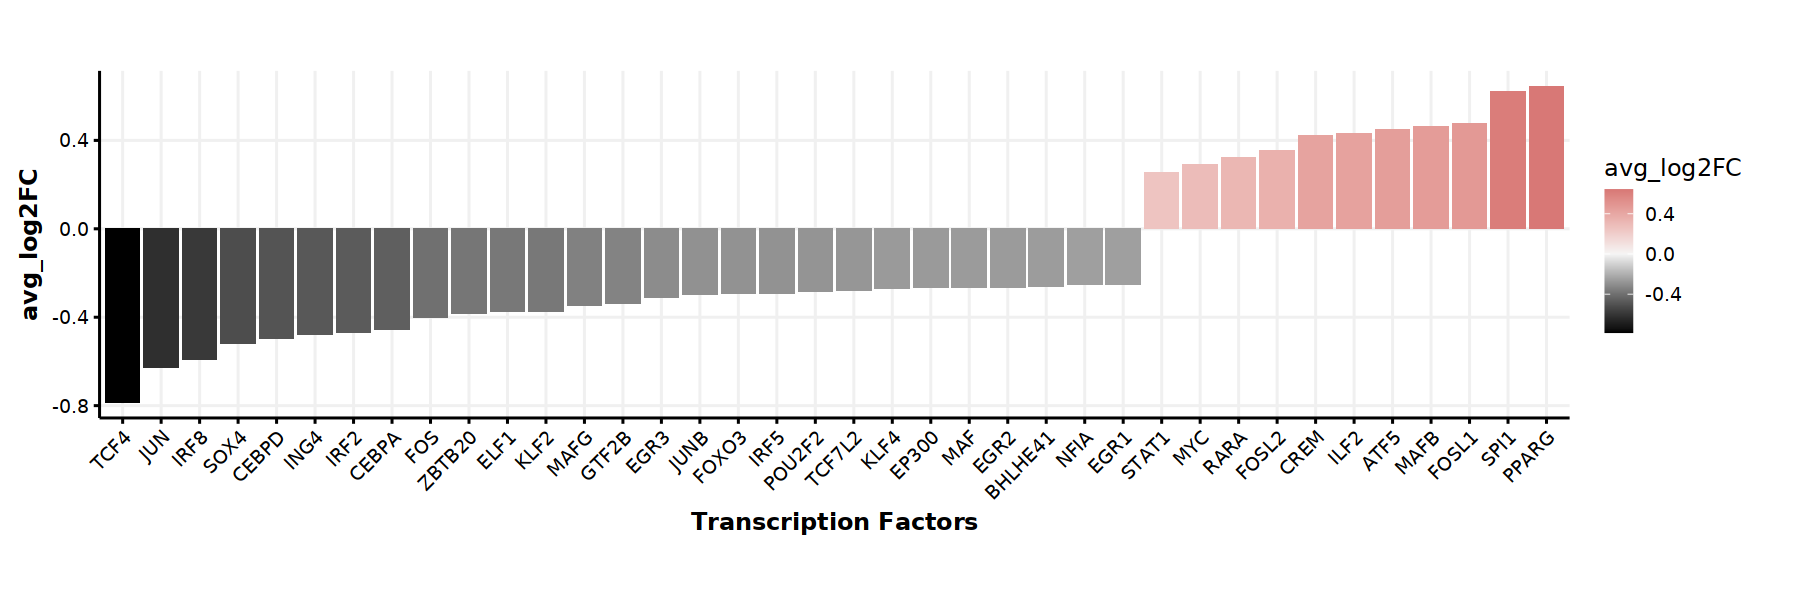

In [92]:
options(repr.plot.width=15, repr.plot.height=5)
# Plot
p <- ggplot(top_genes, aes(x = reorder(gene, avg_log2FC), y = avg_log2FC)) + 
    geom_bar(aes(fill = avg_log2FC), stat = "identity") +
    scale_fill_gradient2(low = "black", high = "indianred", 
        mid = "whitesmoke", midpoint = 0) + 
    theme_Publication()+RotatedAxis() +
    xlab("Transcription Factors")


pdf('Figure3_A.pdf',width = 15,height=5)
p
dev.off()

p

In [91]:


# Define the path to the adjacency matrix CSV file
adj_mat <- '8.SCENIC/Metacells/output/2024_04_01_Metacells_Data_adj_ext.csv'

# Read the adjacency matrix CSV file
adj <- read.csv(adj_mat)

# View the structure of the data frame
str(adj)


'data.frame':	701210 obs. of  3 variables:
 $ TF        : chr  "ZBTB16" "FOS" "KDM5D" "FOS" ...
 $ target    : chr  "FKBP5" "IER2" "DDX3Y" "TSC22D3" ...
 $ importance: num  67.4 56.8 56.7 56.6 53.9 ...


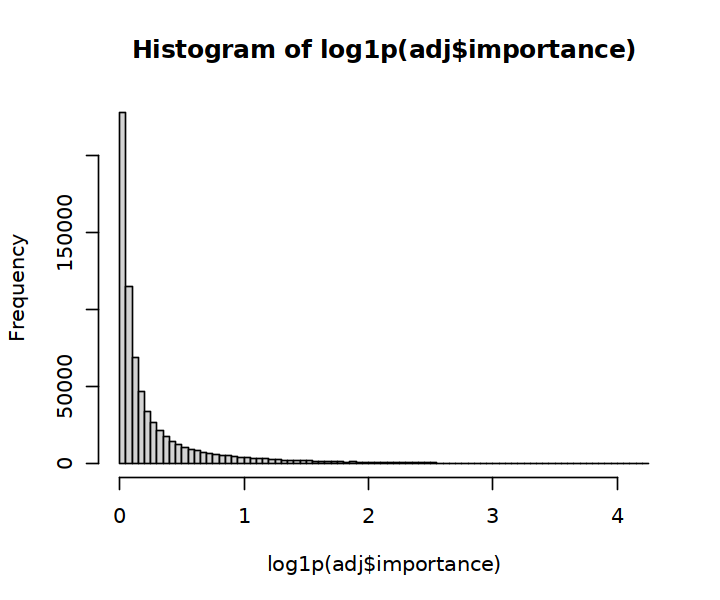

In [18]:
# Set plot size options
options(repr.plot.width = 6, repr.plot.height = 5)

# Create a histogram of logarithm of importance values
hist(log1p(adj$importance), breaks = 100)


In [37]:
# Set the importance threshold and number of targets
importance_threshold <- 2
n_of_targets <- 20

In [38]:
intersect_enriched_dfs <- top_genes$gene 


In [39]:
# Set a random seed for reproducibility
set.seed(12345678)
library(igraph)
# Sewt the Top DE TFs tto pus as hubs
regulon.names<- intersect_enriched_dfs
# Find all the lines of the adj matrix with the TFs as senders
adj1 <- adj[adj$TF %in% regulon.names,]
# Find the top n connections of the TFs based on the importance
adj2 <- adj1 %>% group_by(TF) %>% top_n(n = n_of_targets, wt = importance)
# Combine the TFs and their targets to add to the network
tf_to_keep<- unique(c(adj2$TF,adj2$target,regulon.names))
# Filter the adj matrix keeping as the TFs the top ones and as targets the Tfs and their top targets
adj_to_plot <- adj %>% filter(TF %in% regulon.names, target %in%tf_to_keep) #regulon.names
# Keep only the conections with importance higher than importance threshold
adj_to_plot_filtered <- adj_to_plot %>% filter(log1p(importance)>importance_threshold)


In [40]:
set.seed(12345678)
## generate network
edge.df <- adj_to_plot_filtered
colnames(edge.df) <- c('from', 'to', 'weights')
edge.df$from <- as.character(edge.df$from)
edge.df$to <- as.character(edge.df$to)
edge.df <- edge.df%>%na.omit()
# Set the vertex names
vertex <- unique(c(edge.df$from, edge.df$to))
# Create the graph oh the connections
net <- graph_from_data_frame(d = edge.df, vertices = vertex, directed = T)


In [41]:
# Identify unique vertices from 'TF' and 'target' columns of adj_to_plot_filtered
all_vertex <- unique(c(adj_to_plot_filtered$TF, adj_to_plot_filtered$target))

# Filter out vertices that are present in the row names of RNA counts data from Metacells_2
vertex_in_RNA <- all_vertex[all_vertex %in% rownames(Metacells_2@assays$RNA@counts)]

# Sort the filtered vertices
sorted_vertex_in_RNA <- sort(vertex_in_RNA)

# Display the sorted vertices
#sorted_vertex_in_RNA


In [42]:
# Set cluster identities in Metacells object
Idents(Metacells) <- 'TwoClusters'

# Perform differential expression analysis
FC_NET <- FindMarkers(
  Metacells_2,  # Metacells_2 object
  ident.1 = 'MTC_456',  # Cluster 1
  ident.2 = 'MTC_123',  # Cluster 2
  logfc.threshold = 0,  # Log fold change threshold
  assay = 'RNA',  # Assay type
  min.pct = 0,  # Minimum percentage
  return.thresh = 1,  # Return threshold
  features = vertex_in_RNA  # Features to analyze
)

# Assign gene names as a separate column
FC_NET$gene <- rownames(FC_NET)


In [43]:
# Add a column 'cluster' to FC_NET based on avg_log2FC values
FC_NET$cluster <- ifelse(FC_NET$avg_log2FC > 0, 'B', 'G')

# Extract gene names for downregulated genes
dn.deg <- FC_NET$gene[FC_NET$avg_log2FC < 0]

# Extract gene names for upregulated genes
up.deg <- FC_NET$gene[FC_NET$avg_log2FC > 0]


In [44]:
# Remove parentheses from regulon names
regulons_plain <- gsub("[(+)]", "", names(regulons))

# Filter regulons to include only those present in unique genes from top_genes
gene_sets_list_c <- regulons[regulons_plain %in% unique(top_genes$gene)]

# Count the occurrences of genes in the filtered gene sets and sort the result
tail(sort(table(unlist(gene_sets_list_c))))

# Assuming 'vertex' is defined elsewhere, order FC_NET based on 'vertex'
Ordered_FC_NET <- FC_NET[vertex,]

# Display the first few rows of Ordered_FC_NET
head(Ordered_FC_NET)



  YPEL5   INTS6   OTUD1    TCF4   PELI1 TSC22D2 
     11      12      12      12      13      13 

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,gene,cluster
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
FOS,0,-1.4063394,1.000,1.000,0,FOS,G
EGR1,0,-0.9003209,0.989,0.999,0,EGR1,G
JUNB,0,-0.9583812,1.000,1.000,0,JUNB,G
CEBPD,0,-0.8534512,0.991,0.996,0,CEBPD,G
JUN,0,-1.7461646,0.998,1.000,0,JUN,G
MAF,0,-2.2603117,0.972,1.000,0,MAF,G


In [45]:
# Create a empty label list in the length of the verticies
vlabel <- rep("", length(vertex))
# Set the size of the vertex based on the importance of the connection
vsize <- scale(edge.df$weights, center = min(quantile(edge.df$weights)), scale = max(quantile(edge.df$weights)) - min(quantile(edge.df$weights)))
# Set the vertex size based on log2FC
avg_log2FC <- Ordered_FC_NET$avg_log2FC

degrees <- igraph::degree(net)
vsize <- scale(degrees, center = min(quantile(degrees)), scale = max(quantile(degrees)) - min(quantile(degrees)))

# Set the size of the edge based on the importance of the connection
esize <- scale(edge.df$weights, 0, 5)

# Set the average fold change in a variable to be used as alpha in the color
vcl <-Ordered_FC_NET$avg_log2FC
alph <- Ordered_FC_NET$avg_log2FC

vcl <- ifelse(vertex %in% up.deg, 'red', ifelse(vertex %in% dn.deg, 'blue', 'grey'))

vertex_shape <- names(vcl)


In [46]:
names(vcl) <- vertex
vcl[is.na(vcl)] <- 0
# Create a custom color palette
color_palette <- colorRampPalette(c("lightskyblue1", "white", "red"))(length(vcl))
# Assign colors to your numeric vector
colors <- color_palette[rank(vcl)]

[1] "FOS"        "EGR1"       "JUNB"       "CEBPD"      "JUN"       
  [6] "MAF"        "EGR2"       "BHLHE41"    "KLF2"       "EGR3"      
 [11] "FOSL2"      "MAFB"       "KLF4"       "CREM"       "POU2F2"    
 [16] "NFIA"       "ATF5"       "STAT1"      "IRF8"       "FOXO3"     
 [21] "CEBPA"      "SPI1"       "MYC"        "TCF4"       "MAFG"      
 [26] "PPARG"      "ZBTB20"     "ELF1"       "IER2"       "TSC22D3"   
 [31] "BTG2"       "CH25H"      "CEBPB"      "DDIT4"      "CX3CR1"    
 [36] "CD83"       "FOSB"       "CDKN1A"     "IGSF6"      "DNAJB1"    
 [41] "CCL3"       "AC020916.1" "HSPH1"      "LTC4S"      "PMEPA1"    
 [46] "HSPA1B"     "RGS1"       "SORL1"      "P2RY12"     "SALL1"     
 [51] "SPP1"       "UBB"        "P2RY13"     "KLF6"       "SELPLG"    
 [56] "HP1BP3"     "IL6ST"      "RASSF8"     "HSP90AB1"   "ZFP36"     
 [61] "CD163"      "SLC11A1"    "RHOB"       "MRC1"       "IL1B"      
 [66] "ENO1"       "TAGAP"      "APBB1IP"    "C3"         "NFKBIA"    
 [71] "ATM"        "FCER1G"     "MYADM"      "MT2A"       "HIF1A"     
 [76] "TIAM1"      "SPRY1"      "MARCKS"     "EPB41L2"    "MIS18BP1"  
 [81] "LGALS1"     "TNF"        "EMP3"       "ITPR2"      "INTS6"     
 [86] "JUND"       "CLK1"       "ANXA2"      "MEF2C"      "METTL7A"   
 [91] "CXorf21"    "SLC1A3"     "CITED2"     "CSRNP1"     "BOD1L1"    
 [96] "CCNL1"      "HNRNPA0"    "MSR1"       "OTULINL"    "OTUD1"     
[101] "LDHA"       "ERF"        "IER5"       "SHTN1"      "PPP1R15A"  
[106] "RGS2"       "SERTAD1"    "DNAJB4"     "PLIN2"      "SLC3A2"    
[111] "TSC22D2"    "SRSF7"      "QKI"        "CD63"       "CCL3L1"    
[116] "S100A11"    "FOLR2"      "ADGRE2"     "BLNK"       "GLIPR1"    
[121] "NR4A2"      "SYNDIG1"    "TYMP"       "GNAS"       "SUCNR1"    
[126] "SH3BGRL3"   "ATF4"       "CLEC9A"     "NFKBID"     "HLA-DMB"   
[131] "DNAJA1"     "FABP5"      "ZFP36L1"    "SLC4A7"     "ARID5B"    
[136] "ZFHX3"      "FKBP5"      "ZFAND2A"    "GAPDH"      "IER3"      
[141] "YPEL3"      "ZFP36L2"    "PLK2"       "NR4A1"      "MIDN"      
[146] "HIVEP3"     "CLEC5A"     "PLAUR"      "IFI30"      "NFKBIZ"    
[151] "VSIG4"      "IVNS1ABP"   "NRIP1"      "ANKRD44"    "AL392172.2"
[156] "SERPINE1"   "NR4A3"      "HERPUD1"    "GARS-DT"    "IL4I1"     
[161] "IFI44L"     "VEGFA"      "GIMAP1"     "GIMAP4"     "SOCS3"     
[166] "PPP1R10"    "DOCK4"      "NEU1"       "STX4"       "TUBA1C"    
[171] "ITM2C"      "IFI6"       "GRASP"      "NLRP3"      "HSPB1"     
[176] "LPL"        "NAMPT"      "DDX3X"      "CD9"        "ABCG2"     
[181] "PIP5K1B"    "GPR137B"    "INS"        "GPR65"      "HBEGF"     
[186] "TNFAIP3"    "OGT"        "MBOAT7"     "GNA13"      "G0S2"      
[191] "GTF2B"      "DUSP4"      "RGS16"      "FCGR1B"     "FOXN3"     
[196] "TCOF1"      "NEK6"       "TRIB1"      "ODC1"       "AC253572.2"
[201] "BHLHE40"    "OLFML3"     "CSGALNACT1" "CXADR"      "SPHK1"     
[206] "ATF3"       "GIMAP7"     "PIM1"       "USF2"       "EIF5A"     
[211] "FMNL3"      "SIGLEC9"    "IQGAP1"     "SIGLEC8"    "CIITA"     
[216] "FAM53C"     "PGK1"       "TGFBR1"     "ARID1B"     "IFITM2"    
[221] "C5AR1"      "NHLRC3"     "MYO1G"      "PPP1R35"    "APOE"      
[226] "PPDPF"      "ADA2"       "ATP13A3"    "IRF2"       "KCTD7"     
[231] "RGCC"       "KANSL1"     "ARHGAP18"   "CCL2"       "SAP30"     
[236] "XBP1"       "ZMYND8"     "FP700111.1" "ID2"        "CALM1"     
[241] "DSE"        "TTC14"      "SGK1"       "LY6E"       "MPP1"      
[246] "PGAM1"      "PIH1D1"     "UPP1"       "ETS2"       "FKBP1A"    
[251] "HSPA5"      "RNASE1"     "DHRS9"      "ANKRD22"    "PDPN"      
[256] "CALCR"      "CDCP1"      "ENG"        "FAM135A"    "CD14"      
[261] "RELB"       "LYST"       "PADI2"      "H1FX"       "DNASE2"    
[266] "CXCR4"      "PSME2"      "NME1"       "RAMP1"      "ANKRD11"   
[271] "PTGS2"      "SMAD2"      "ANXA5"      "PTPN7"      "MIF"       
[276] "ISG15"      "ZMAT3"      "CLIC1"      "PPP1R15B"   "TNFRSF1B"  
[281] "METRNL"     "NFIL3"

[1] "triangle" "triangle" "triangle" "triangle" "triangle" "triangle"
  [7] "triangle" "triangle" "triangle" "triangle" "triangle" "triangle"
 [13] "triangle" "triangle" "triangle" "triangle" "triangle" "triangle"
 [19] "triangle" "triangle" "triangle" "triangle" "triangle" "triangle"
 [25] "triangle" "triangle" "triangle" "triangle" "circle"   "circle"  
 [31] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
 [37] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
 [43] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
 [49] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
 [55] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
 [61] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
 [67] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
 [73] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
 [79] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
 [85] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
 [91] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
 [97] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[103] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[109] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[115] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[121] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[127] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[133] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[139] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[145] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[151] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[157] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[163] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[169] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[175] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[181] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[187] "circle"   "circle"   "circle"   "circle"   "triangle" "circle"  
[193] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[199] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[205] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[211] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[217] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[223] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[229] "triangle" "circle"   "circle"   "circle"   "circle"   "circle"  
[235] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[241] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[247] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[253] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[259] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[265] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[271] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[277] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[283] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[289] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[295] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[301] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[307] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[313] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[319] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[325] "circle"   "circle"   "circle"   "circle"   "circle"   "circle"  
[331] "circle"   "circle"   "circle"   "ci

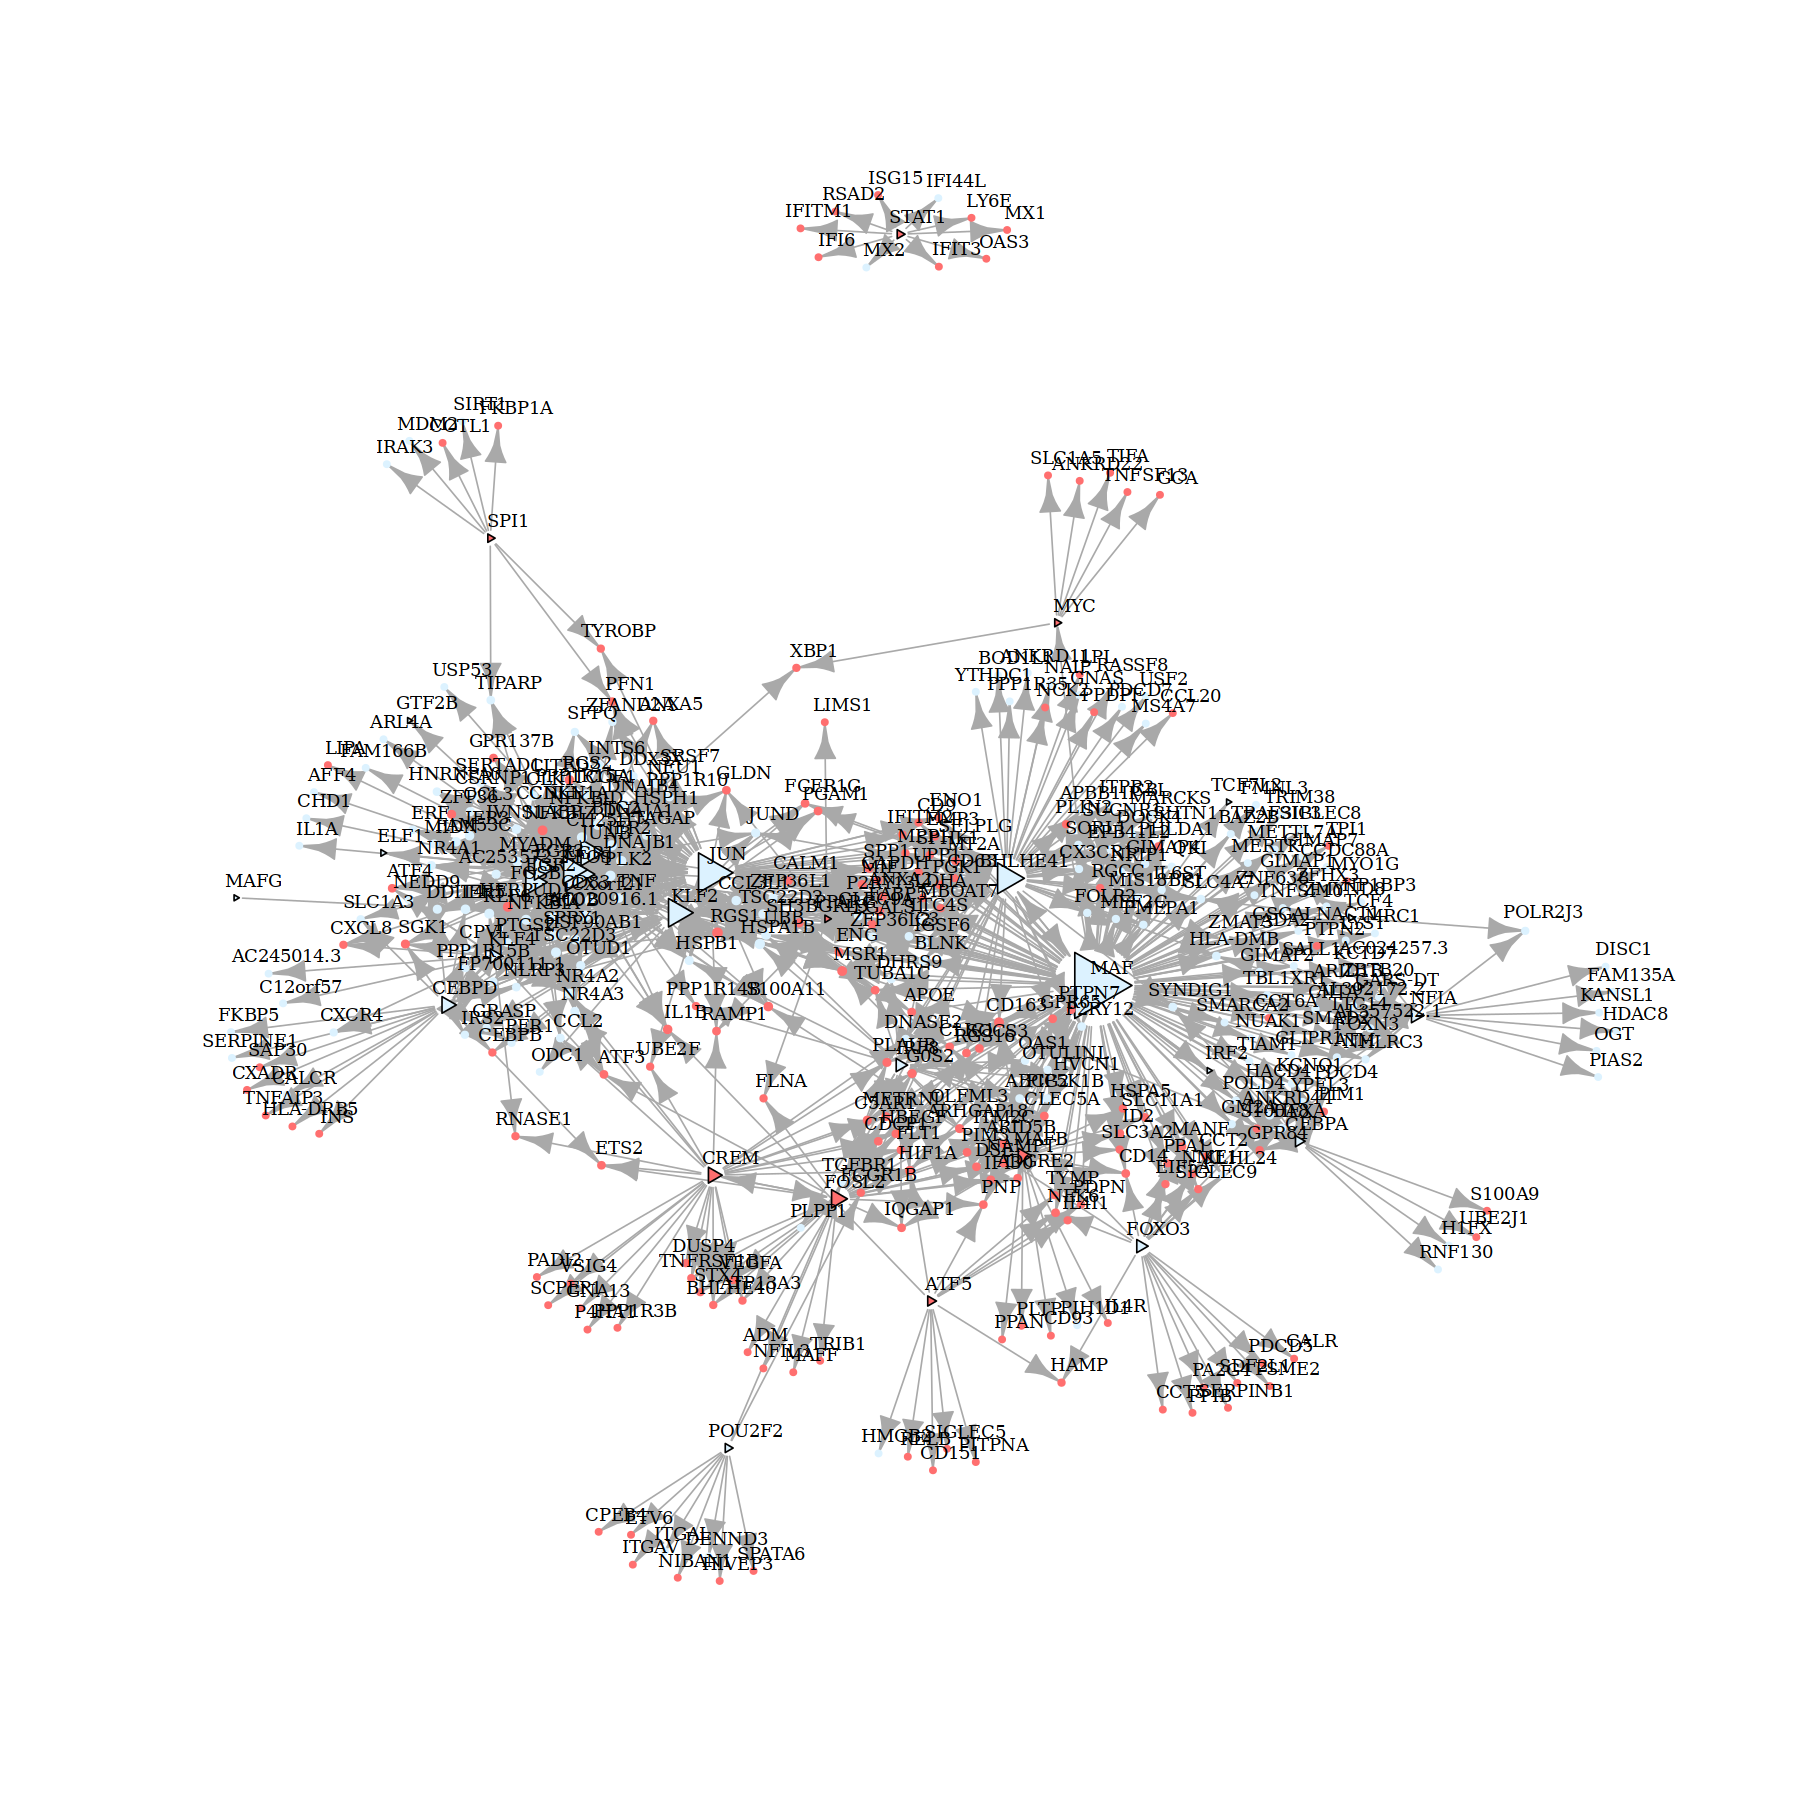

In [47]:
set.seed(12345678)
# set.seed(88888888)

# triangle vertex shape
mytriangle <- function(coords, v=NULL, params) {
  vertex.color <- params("vertex", "color")
  if (length(vertex.color) != 1 && !is.null(v)) {
    vertex.color <- vertex.color[v]
  }
  vertex.size <- 1/200 * params("vertex", "size")
  if (length(vertex.size) != 1 && !is.null(v)) {
    vertex.size <- vertex.size[v]
  }

  symbols(x=coords[,1], y=coords[,2], bg=vertex.color,
          stars=cbind(vertex.size, vertex.size, vertex.size),
          add=TRUE, inches=FALSE)
}


# clips as a circle
add_shape("triangle", clip=shapes("circle")$clip,
                 plot=mytriangle)

vertex_shape <- rep("circle",length(names(vcl)))
vertex_shape[names(vcl)%in% intersect_enriched_dfs] <- 'triangle'
names(vcl)
vertex_shape



options(repr.plot.width=15, repr.plot.height=15)
plot(
    net,
    #vertex.label = vlabel,
    vertex.shape=vertex_shape,
    vertex.label.cex = 0.85,
    vertex.label.dist = 0.5,
    vertex.label.color = 'black',
    vertex.size = c( vsize+0.1)*10,
    vertex.frame.color = NA,
    edge.arrow.size =0.5, 
    vertex.color =colors, 
  )

In [48]:
# Define new shapes for vertices based on the existing shape attribute
vertex_shape2 <- ifelse(vertex_shape == 'circle', 'rectangle', 'octagon') 

# Set colors and shapes for vertices
V(net)$color <- colors  # Assign colors to vertices
V(net)$shape <- vertex_shape2  # Assign shapes to vertices

# Calculate scaled values for vertex sizes based on the degree centrality
original_vector <- igraph::degree(net)  # Compute degree centrality for each vertex

# Define new min and max values for scaling
new_min <- 30  # New minimum size
new_max <- 100  # New maximum size

# Scale the degree centrality values to the new range
scaled_vector <- (original_vector - min(original_vector)) * (new_max - new_min) / (max(original_vector) - min(original_vector)) + new_min

# Assign scaled sizes to vertices
V(net)$size <- scaled_vector

In [49]:
# Compute the degree centrality for each vertex in the network and store it in 'Nums'
Nums <- igraph::degree(net)

# Get the names of the vertices in the network and store them in 'Names'
Names <- names(igraph::degree(net))

# Check which vertex names are present in the 'intersect_enriched_dfs' vector
Indexes <- Names %in% intersect_enriched_dfs

# Create a dataframe 'data' containing the vertex names and their corresponding degree centrality
data <- as.data.frame(cbind(Nums, Names))[Indexes,]

# Convert the 'Nums' column to numeric
data$Nums <- as.numeric(data$Nums)

# Arrange the dataframe in descending order of the 'Nums' column
data <- data %>% arrange(desc(Nums))

# Convert the 'Names' column to a factor with levels set to the original order of names
data$Names <- factor(data$Names, levels = data$Names)

data$cluster <- deg_pa[as.vector(data$Names),'cluster']


In [66]:
data

,Nums,Names,cluster
,<dbl>,<fct>,<chr>
MAF,576,MAF,Good
BHLHE41,249,BHLHE41,Good
JUN,203,JUN,Good
FOS,135,FOS,Good
KLF2,114,KLF2,Good
JUNB,105,JUNB,Good
EGR1,102,EGR1,Good
EGR2,80,EGR2,Good
EGR3,64,EGR3,Good


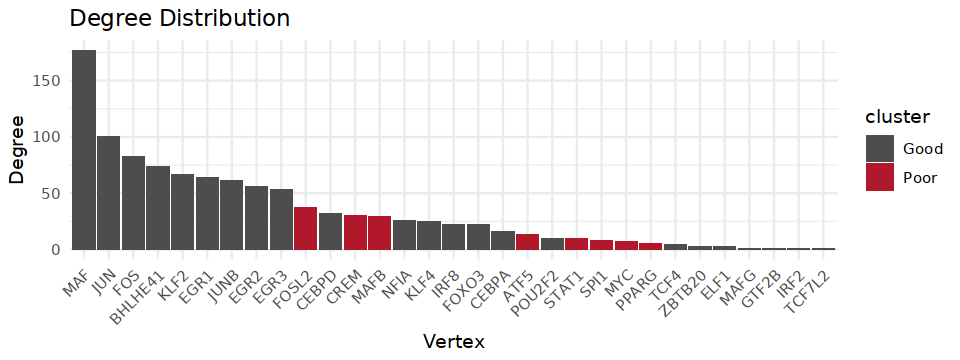

In [50]:
# Set plot size options
options(repr.plot.width = 8, repr.plot.height = 3)
# cols = c(colors_rb[c(1,6)])
# Create a ggplot bar plot
ggplot(data, aes(x = Names, y = Nums,fill=cluster)) +  # Define x and y aesthetics
  geom_bar(stat = "identity") +# Use geom_bar to create bar plot
  scale_fill_manual(values=c(colors_rb[c(1,6)])) + 
  labs(x = "Vertex", y = "Degree", title = "Degree Distribution") +  # Set axis labels and title
  theme_minimal() +  # Apply minimal theme
  theme(axis.text.x = element_text(angle = 45, hjust = 1))  # Rotate x-axis labels for better readability




In [51]:
sessionInfo()


R version 4.3.0 (2023-04-21)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 21.04

Matrix products: default
BLAS/LAPACK: /sc/arion/work/kyriad02/miniconda3/envs/dreamlet430/lib/libopenblasp-r0.3.23.so;  LAPACK version 3.11.0

locale:
[1] C

time zone: America/New_York
tzcode source: system (glibc)

attached base packages:
 [1] grid      parallel  stats4    stats     graphics  grDevices utils    
 [8] datasets  methods   base     

other attached packages:
 [1] ggthemes_4.2.4              AUCell_1.22.0              
 [3] SCENIC_1.3.1                metafor_4.2-0              
 [5] numDeriv_2016.8-1.1         metadat_1.2-0              
 [7] Matrix_1.5-4.1              broom_1.0.5                
 [9] muscat_1.14.0               ComplexHeatmap_2.16.0      
[11] circlize_0.4.15             aplot_0.1.10               
[13] ggtree_3.8.0                doParallel_1.0.17          
[15] iterators_1.0.14            foreach_1.5.2              
[17] scater_1.28.0               sc

# ===== Plot the full Degrees ===========

In [52]:
# Set the importance threshold and number of targets
importance_threshold <- 2
n_of_targets <- 1000

In [53]:
intersect_enriched_dfs <- top_genes$gene 


In [54]:
# Set a random seed for reproducibility
set.seed(12345678)
library(igraph)
# Sewt the Top DE TFs tto pus as hubs
regulon.names<- intersect_enriched_dfs
# Find all the lines of the adj matrix with the TFs as senders
adj1 <- adj[adj$TF %in% regulon.names,]
# Find the top n connections of the TFs based on the importance
adj2 <- adj1 %>% group_by(TF) %>% top_n(n = n_of_targets, wt = importance)
# Combine the TFs and their targets to add to the network
tf_to_keep<- unique(c(adj2$TF,adj2$target,regulon.names))
# Filter the adj matrix keeping as the TFs the top ones and as targets the Tfs and their top targets
adj_to_plot <- adj %>% filter(TF %in% regulon.names, target %in%tf_to_keep) #regulon.names
# Keep only the conections with importance higher than importance threshold
adj_to_plot_filtered <- adj_to_plot %>% filter(log1p(importance)>importance_threshold)


In [55]:
set.seed(12345678)
## generate network
edge.df <- adj_to_plot_filtered
colnames(edge.df) <- c('from', 'to', 'weights')
edge.df$from <- as.character(edge.df$from)
edge.df$to <- as.character(edge.df$to)
edge.df <- edge.df%>%na.omit()
# Set the vertex names
vertex <- unique(c(edge.df$from, edge.df$to))
# Create the graph oh the connections
net_big <- graph_from_data_frame(d = edge.df, vertices = vertex, directed = T)


In [56]:
# Identify unique vertices from 'TF' and 'target' columns of adj_to_plot_filtered
all_vertex <- unique(c(adj_to_plot_filtered$TF, adj_to_plot_filtered$target))

# Filter out vertices that are present in the row names of RNA counts data from Metacells_2
vertex_in_RNA <- all_vertex[all_vertex %in% rownames(Metacells_2@assays$RNA@counts)]

# Sort the filtered vertices
sorted_vertex_in_RNA <- sort(vertex_in_RNA)

# Display the sorted vertices
#sorted_vertex_in_RNA


In [57]:
# Set cluster identities in Metacells object
Idents(Metacells) <- 'TwoClusters'

# Perform differential expression analysis
FC_NET <- FindMarkers(
  Metacells_2,  # Metacells_2 object
  ident.1 = 'MTC_456',  # Cluster 1
  ident.2 = 'MTC_123',  # Cluster 2
  logfc.threshold = 0,  # Log fold change threshold
  assay = 'RNA',  # Assay type
  min.pct = 0,  # Minimum percentage
  return.thresh = 1,  # Return threshold
  features = vertex_in_RNA  # Features to analyze
)

# Assign gene names as a separate column
FC_NET$gene <- rownames(FC_NET)


In [58]:
# Add a column 'cluster' to FC_NET based on avg_log2FC values
FC_NET$cluster <- ifelse(FC_NET$avg_log2FC > 0, 'B', 'G')

# Extract gene names for downregulated genes
dn.deg <- FC_NET$gene[FC_NET$avg_log2FC < 0]

# Extract gene names for upregulated genes
up.deg <- FC_NET$gene[FC_NET$avg_log2FC > 0]


In [59]:
# Remove parentheses from regulon names
regulons_plain <- gsub("[(+)]", "", names(regulons))

# Filter regulons to include only those present in unique genes from top_genes
gene_sets_list_c <- regulons[regulons_plain %in% unique(top_genes$gene)]

# Count the occurrences of genes in the filtered gene sets and sort the result
tail(sort(table(unlist(gene_sets_list_c))))

# Assuming 'vertex' is defined elsewhere, order FC_NET based on 'vertex'
Ordered_FC_NET <- FC_NET[vertex,]

# Display the first few rows of Ordered_FC_NET
head(Ordered_FC_NET)



  YPEL5   INTS6   OTUD1    TCF4   PELI1 TSC22D2 
     11      12      12      12      13      13 

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,gene,cluster
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
FOS,0,-1.4063394,1.000,1.000,0,FOS,G
EGR1,0,-0.9003209,0.989,0.999,0,EGR1,G
JUNB,0,-0.9583812,1.000,1.000,0,JUNB,G
CEBPD,0,-0.8534512,0.991,0.996,0,CEBPD,G
JUN,0,-1.7461646,0.998,1.000,0,JUN,G
MAF,0,-2.2603117,0.972,1.000,0,MAF,G


In [60]:
# Create a empty label list in the length of the verticies
vlabel <- rep("", length(vertex))
# Set the size of the vertex based on the importance of the connection
vsize <- scale(edge.df$weights, center = min(quantile(edge.df$weights)), scale = max(quantile(edge.df$weights)) - min(quantile(edge.df$weights)))
# Set the vertex size based on log2FC
avg_log2FC <- Ordered_FC_NET$avg_log2FC

degrees <- igraph::degree(net_big)
vsize <- scale(degrees, center = min(quantile(degrees)), scale = max(quantile(degrees)) - min(quantile(degrees)))

# Set the size of the edge based on the importance of the connection
esize <- scale(edge.df$weights, 0, 5)

# Set the average fold change in a variable to be used as alpha in the color
vcl <-Ordered_FC_NET$avg_log2FC
alph <- Ordered_FC_NET$avg_log2FC

vcl <- ifelse(vertex %in% up.deg, 'red', ifelse(vertex %in% dn.deg, 'blue', 'grey'))

vertex_shape <- names(vcl)


In [61]:
names(vcl) <- vertex
vcl[is.na(vcl)] <- 0
# Create a custom color palette
color_palette <- colorRampPalette(c("lightskyblue1", "white", "red"))(length(vcl))
# Assign colors to your numeric vector
colors <- color_palette[rank(vcl)]

In [ ]:
set.seed(12345678)
# set.seed(88888888)

# triangle vertex shape
mytriangle <- function(coords, v=NULL, params) {
  vertex.color <- params("vertex", "color")
  if (length(vertex.color) != 1 && !is.null(v)) {
    vertex.color <- vertex.color[v]
  }
  vertex.size <- 1/200 * params("vertex", "size")
  if (length(vertex.size) != 1 && !is.null(v)) {
    vertex.size <- vertex.size[v]
  }

  symbols(x=coords[,1], y=coords[,2], bg=vertex.color,
          stars=cbind(vertex.size, vertex.size, vertex.size),
          add=TRUE, inches=FALSE)
}


# clips as a circle
add_shape("triangle", clip=shapes("circle")$clip,
                 plot=mytriangle)

vertex_shape <- rep("circle",length(names(vcl)))
vertex_shape[names(vcl)%in% intersect_enriched_dfs] <- 'triangle'
names(vcl)
vertex_shape



options(repr.plot.width=15, repr.plot.height=15)
plot(
    net,
    #vertex.label = vlabel,
    vertex.shape=vertex_shape,
    vertex.label.cex = 0.85,
    vertex.label.dist = 0.5,
    vertex.label.color = 'black',
    vertex.size = c( vsize+0.1)*10,
    vertex.frame.color = NA,
    edge.arrow.size =0.5, 
    vertex.color =colors, 
  )

In [63]:
# Define new shapes for vertices based on the existing shape attribute
vertex_shape2 <- ifelse(vertex_shape == 'circle', 'rectangle', 'octagon') 

# Set colors and shapes for vertices
V(net)$color <- colors  # Assign colors to vertices
V(net)$shape <- vertex_shape2  # Assign shapes to vertices

# Calculate scaled values for vertex sizes based on the degree centrality
original_vector <- igraph::degree(net)  # Compute degree centrality for each vertex

# Define new min and max values for scaling
new_min <- 30  # New minimum size
new_max <- 100  # New maximum size

# Scale the degree centrality values to the new range
scaled_vector <- (original_vector - min(original_vector)) * (new_max - new_min) / (max(original_vector) - min(original_vector)) + new_min

# Assign scaled sizes to vertices
V(net)$size <- scaled_vector

In [64]:
# Compute the degree centrality for each vertex in the network and store it in 'Nums'
Nums <- igraph::degree(net)

# Get the names of the vertices in the network and store them in 'Names'
Names <- names(igraph::degree(net))

# Check which vertex names are present in the 'intersect_enriched_dfs' vector
Indexes <- Names %in% intersect_enriched_dfs

# Create a dataframe 'data' containing the vertex names and their corresponding degree centrality
data <- as.data.frame(cbind(Nums, Names))[Indexes,]

# Convert the 'Nums' column to numeric
data$Nums <- as.numeric(data$Nums)

# Arrange the dataframe in descending order of the 'Nums' column
data <- data %>% arrange(desc(Nums))

# Convert the 'Names' column to a factor with levels set to the original order of names
data$Names <- factor(data$Names, levels = data$Names)

data$cluster <- deg_pa[as.vector(data$Names),'cluster']


png 
  2

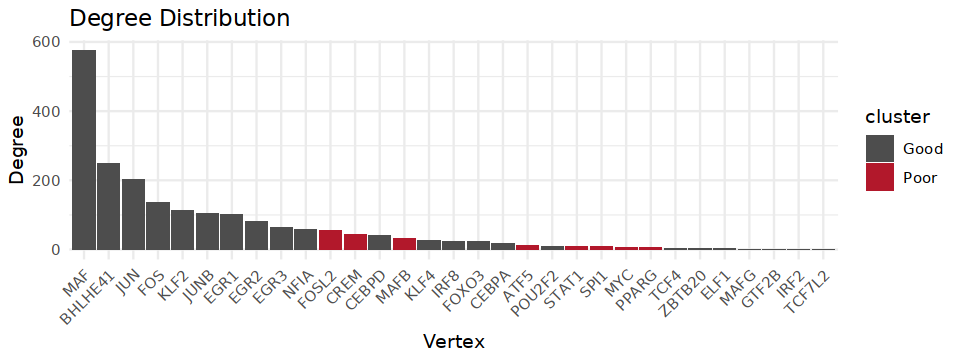

In [94]:
# Set plot size options
options(repr.plot.width = 8, repr.plot.height = 3)
# cols = c(colors_rb[c(1,6)])
# Create a ggplot bar plot
p <- ggplot(data, aes(x = Names, y = Nums,fill=cluster)) +  # Define x and y aesthetics
  geom_bar(stat = "identity") +# Use geom_bar to create bar plot
  scale_fill_manual(values=c(colors_rb[c(1,6)])) + 
  labs(x = "Vertex", y = "Degree", title = "Degree Distribution") +  # Set axis labels and title
  theme_minimal() +  # Apply minimal theme
  theme(axis.text.x = element_text(angle = 45, hjust = 1))  # Rotate x-axis labels for better readability


pdf('Figures/Figure3_A_Degree.pdf',width = 8,height=3)
p
dev.off()

p

In [95]:
data

,Nums,Names,cluster
,<dbl>,<fct>,<chr>
MAF,576,MAF,Good
BHLHE41,249,BHLHE41,Good
JUN,203,JUN,Good
FOS,135,FOS,Good
KLF2,114,KLF2,Good
JUNB,105,JUNB,Good
EGR1,102,EGR1,Good
EGR2,80,EGR2,Good
EGR3,64,EGR3,Good


In [ ]:
top_genes$gene

In [97]:
top_genes$Degree <-as.numeric(unlist(data[top_genes$gene,'Nums']))

Warning message:
"Removed 7 rows containing missing values or values outside the scale range
(`geom_point()`)."


png 
  2

Warning message:
"Removed 7 rows containing missing values or values outside the scale range
(`geom_point()`)."


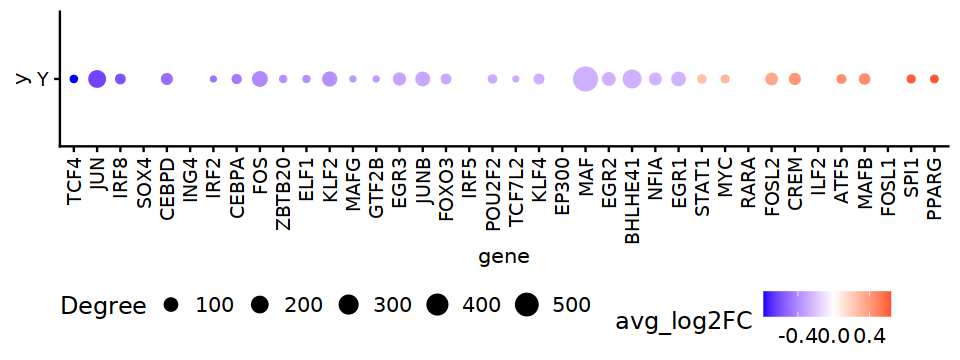

In [99]:
top_genes_ord <- top_genes %>% arrange(avg_log2FC,Degree) 
top_genes_ord$gene <- factor(top_genes_ord$gene,levels=top_genes_ord$gene)
cols=c("blue","red")
p <- ggplot(top_genes_ord,aes(x=gene,y="Y",color=avg_log2FC,size=Degree))+
    geom_point()+
    theme_cowplot()+
    scale_color_gradient2(low = cols[1],mid = 'white', high = cols[2])+
     theme(plot.title = element_text(hjust = 0.5),
             axis.text = element_text(size = 11),  # Adjust font size for axis ticks
           axis.title = element_text(size = 12),
             axis.text.x = element_text(angle = 90,vjust=0.5, hjust = 1))+ theme(legend.position = "bottom")


pdf('Figures/Figure3_A_AlternativePlot_NA.pdf',width = 8,height=3)
p
dev.off()
p

png 
  2

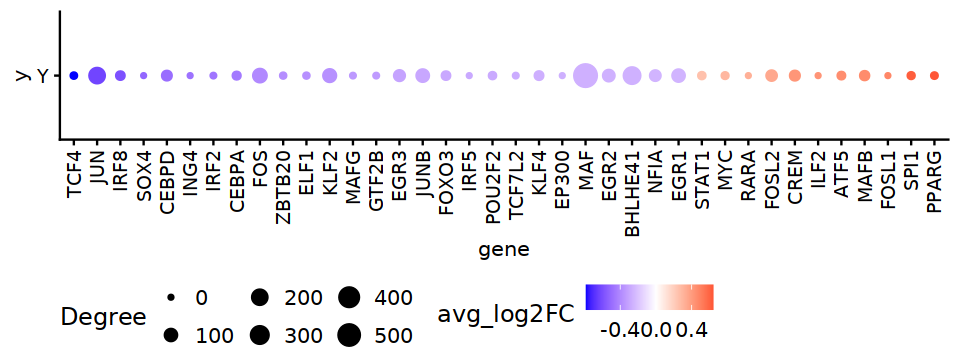

In [100]:
top_genes_ord <- top_genes %>% arrange(avg_log2FC,Degree) 
top_genes_ord$Degree[is.na(top_genes_ord$Degree)] <- 0
top_genes_ord$gene <- factor(top_genes_ord$gene,levels=top_genes_ord$gene)
cols=c("blue","red")
p<-ggplot(top_genes_ord,aes(x=gene,y="Y",color=avg_log2FC,size=Degree))+
    geom_point()+
    theme_cowplot()+
    scale_color_gradient2(low = cols[1],mid = 'white', high = cols[2])+
     theme(plot.title = element_text(hjust = 0.5),
             axis.text = element_text(size = 11),  # Adjust font size for axis ticks
           axis.title = element_text(size = 12),
             axis.text.x = element_text(angle = 90,vjust=0.5, hjust = 1))+ theme(legend.position = "bottom")


pdf('Figures/Figure3_A_AlternativePlot.pdf',width = 8,height=3)
p
dev.off()
p

In [101]:
sessionInfo()

R version 4.3.0 (2023-04-21)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 21.04

Matrix products: default
BLAS/LAPACK: /sc/arion/work/kyriad02/miniconda3/envs/dreamlet430/lib/libopenblasp-r0.3.23.so;  LAPACK version 3.11.0

locale:
[1] C

time zone: America/New_York
tzcode source: system (glibc)

attached base packages:
 [1] grid      parallel  stats4    stats     graphics  grDevices utils    
 [8] datasets  methods   base     

other attached packages:
 [1] ggthemes_4.2.4              AUCell_1.22.0              
 [3] SCENIC_1.3.1                metafor_4.2-0              
 [5] numDeriv_2016.8-1.1         metadat_1.2-0              
 [7] Matrix_1.5-4.1              broom_1.0.5                
 [9] muscat_1.14.0               ComplexHeatmap_2.16.0      
[11] circlize_0.4.15             aplot_0.1.10               
[13] ggtree_3.8.0                doParallel_1.0.17          
[15] iterators_1.0.14            foreach_1.5.2              
[17] scater_1.28.0               sc